# CACE/LATE: Xbox Game Pass Trial Offer with Non-Compliance

Xbox wants to know: **does activating a Game Pass free trial increase long-term spending?**

They randomly offered a free trial to 50K users, but not everyone who was offered actually activated it, and some users in the control group found and activated trials on their own. This is **non-compliance** — the treatment *assigned* (offer) differs from the treatment *received* (activation).

We'll see why naive analysis fails, how ITT is valid but diluted, and how CACE recovers the true treatment effect for compliers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

np.random.seed(42)
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

## Data Simulation

We simulate 100K Xbox users with three latent compliance types:

| Type | % of pop | If offered trial (Z=1) | If not offered (Z=0) | Baseline spending |
|------|----------|----------------------|---------------------|-------------------|
| **Compliers** | 50% | Activate | Don't activate | Normal |
| **Always-takers** | 10% | Activate | Activate anyway | Higher (engaged gamers) |
| **Never-takers** | 40% | Don't activate | Don't activate | Normal |

- **True CACE** = \$18/year for compliers (the causal effect of activation)
- Always-takers have **higher baseline spending** (\$15 more) — this is what makes per-protocol biased
- Always-takers also benefit from activation (\$18 effect), but they activate regardless of assignment

In [2]:
n = 100_000
TRUE_CACE = 18  # true causal effect of activation for compliers (and always-takers)

compliance_type = np.random.choice(
    ['complier', 'always_taker', 'never_taker'],
    size=n,
    p=[0.50, 0.10, 0.40]
)

offered = np.concatenate([np.ones(n // 2, dtype=int), np.zeros(n // 2, dtype=int)])
np.random.shuffle(offered)

activated = np.zeros(n, dtype=int)
activated[(compliance_type == 'complier') & (offered == 1)] = 1
activated[compliance_type == 'always_taker'] = 1
# never_takers: activated stays 0 regardless

baseline_spending = np.random.normal(120, 30, size=n)
baseline_spending[compliance_type == 'always_taker'] += 15  # higher baseline for always-takers

treatment_effect = np.where(activated == 1, TRUE_CACE, 0)
noise = np.random.normal(0, 10, size=n)
spending = baseline_spending + treatment_effect + noise

df = pd.DataFrame({
    'user_id': range(n),
    'offered': offered,
    'activated': activated,
    'compliance_type': compliance_type,
    'spending': spending
})

print(f"Total users: {len(df):,}")
print(f"Offered trial (Z=1): {offered.sum():,}")
print(f"Not offered (Z=0): {(1 - offered).sum():,}")

Total users: 100,000
Offered trial (Z=1): 50,000
Not offered (Z=0): 50,000


## Compliance Breakdown

Let's see who actually activated the trial in each group. This reveals the compliance structure.

In [3]:
compliance_table = pd.crosstab(
    df['compliance_type'], df['offered'],
    values=df['activated'], aggfunc='mean'
).rename(columns={0: 'Control (Z=0)', 1: 'Offered (Z=1)'})
compliance_table.index.name = 'Compliance Type'
compliance_table = compliance_table.loc[['complier', 'always_taker', 'never_taker']]
print("Activation rate by compliance type and assignment:")
print(compliance_table.round(3).to_string())

print("\n--- What the researcher actually observes ---")
print(f"Activation rate in offered group:   {df.loc[df['offered']==1, 'activated'].mean():.3f}")
print(f"Activation rate in control group:   {df.loc[df['offered']==0, 'activated'].mean():.3f}")
print(f"\nThe researcher CANNOT see compliance types — they only see activation rates.")
print(f"The ~60% activation in offered = 50% compliers + 10% always-takers")
print(f"The ~10% activation in control = 10% always-takers")

Activation rate by compliance type and assignment:
offered          Control (Z=0)  Offered (Z=1)
Compliance Type                              
complier                   0.0            1.0
always_taker               1.0            1.0
never_taker                0.0            0.0

--- What the researcher actually observes ---
Activation rate in offered group:   0.600
Activation rate in control group:   0.101

The researcher CANNOT see compliance types — they only see activation rates.
The ~60% activation in offered = 50% compliers + 10% always-takers
The ~10% activation in control = 10% always-takers


## Naive Per-Protocol Analysis (Biased!)

The most tempting analysis: just compare people who activated vs. those who didn't.

**Why this is wrong**: The group of activators is a *mixture* of:
- **Compliers** who activated *because* they were offered → normal baseline spending
- **Always-takers** who would have activated regardless → **higher baseline spending** (\$15 more)

So the activator group has inflated outcomes not because of the treatment, but because always-takers are richer gamers. This is **selection bias** — the very thing randomization was supposed to prevent, undone by conditioning on a post-randomization variable (activation).

In [4]:
mean_activators = df.loc[df['activated'] == 1, 'spending'].mean()
mean_non_activators = df.loc[df['activated'] == 0, 'spending'].mean()
per_protocol = mean_activators - mean_non_activators

print("=== Per-Protocol Analysis (Naive) ===")
print(f"Mean spending among activators:     ${mean_activators:.2f}")
print(f"Mean spending among non-activators: ${mean_non_activators:.2f}")
print(f"Per-protocol estimate:              ${per_protocol:.2f}")
print(f"True CACE:                          ${TRUE_CACE:.2f}")
print(f"\nBias: ${per_protocol - TRUE_CACE:+.2f} (OVERESTIMATES by ~${per_protocol - TRUE_CACE:.0f})")
print(f"\nWhy? Activators include always-takers with $15 higher baseline spending.")
print(f"The per-protocol estimate conflates 'being the kind of person who activates'")
print(f"with 'the causal effect of activating.'")

=== Per-Protocol Analysis (Naive) ===
Mean spending among activators:     $142.38
Mean spending among non-activators: $120.04
Per-protocol estimate:              $22.34
True CACE:                          $18.00

Bias: $+4.34 (OVERESTIMATES by ~$4)

Why? Activators include always-takers with $15 higher baseline spending.
The per-protocol estimate conflates 'being the kind of person who activates'
with 'the causal effect of activating.'


## Why CACE and Not Other Approaches?

We have three options when faced with non-compliance:

| Approach | Verdict | Reasoning |
|----------|---------|----------|
| **Per-protocol** | Biased | Conditions on post-treatment variable (activation). Activators ≠ random sample — they include self-selected always-takers with higher baselines. |
| **ITT** | Valid but diluted | Compares offered vs. not-offered, preserving randomization. But the effect is spread across compliers AND never-takers who weren't affected. Underestimates the actual treatment effect. |
| **CACE** | Correct for compliers | Recovers the treatment effect for people whose behavior was actually changed by the offer. Uses the Wald estimator to "undo" the dilution. |

**We want CACE because**: We want to know the effect of *actually activating Game Pass* for the people whose activation behavior is influenced by the offer — that's the compliers. This is the relevant quantity for deciding whether to expand the trial program.

## Step 1: Intent-to-Treat (ITT) Estimate

Compare outcomes by **assignment** (offered vs. not offered), ignoring whether anyone actually activated.

This is unbiased because it respects randomization. But it's diluted — the effect is averaged over compliers (who benefit) AND never-takers (who aren't affected), pulling the estimate toward zero.

In [5]:
mean_offered = df.loc[df['offered'] == 1, 'spending'].mean()
mean_control = df.loc[df['offered'] == 0, 'spending'].mean()
itt = mean_offered - mean_control

print("=== Intent-to-Treat (ITT) ===")
print(f"Mean spending (offered):     ${mean_offered:.2f}")
print(f"Mean spending (not offered): ${mean_control:.2f}")
print(f"ITT estimate:                ${itt:.2f}")
print(f"True CACE:                   ${TRUE_CACE:.2f}")
print(f"\nITT < True CACE because only ~50% of the offered group are compliers.")
print(f"The other ~50% (never-takers + always-takers in both arms) dilute the signal.")
print(f"\nITT ≈ CACE × compliance_rate = {TRUE_CACE} × 0.50 = {TRUE_CACE * 0.50:.1f}")

=== Intent-to-Treat (ITT) ===
Mean spending (offered):     $132.35
Mean spending (not offered): $123.38
ITT estimate:                $8.97
True CACE:                   $18.00

ITT < True CACE because only ~50% of the offered group are compliers.
The other ~50% (never-takers + always-takers in both arms) dilute the signal.

ITT ≈ CACE × compliance_rate = 18 × 0.50 = 9.0


## Step 2: Compliance Rate (First Stage)

The compliance rate is the difference in activation rates between the offered and control groups:

$$\text{Compliance Rate} = P(T=1 \mid Z=1) - P(T=1 \mid Z=0)$$

This measures the fraction of the population whose treatment status is actually *moved* by the instrument — i.e., the compliers.

In [6]:
activation_offered = df.loc[df['offered'] == 1, 'activated'].mean()
activation_control = df.loc[df['offered'] == 0, 'activated'].mean()
compliance_rate = activation_offered - activation_control

print("=== Compliance Rate (First Stage) ===")
print(f"P(activated | offered):     {activation_offered:.4f}")
print(f"P(activated | not offered): {activation_control:.4f}")
print(f"Compliance rate:            {compliance_rate:.4f}")
print(f"\nThis means ~{compliance_rate:.0%} of users are compliers — their activation")
print(f"behavior is moved by the offer.")
print(f"\nNote: activation in control ({activation_control:.1%}) comes from always-takers")
print(f"who find and activate trials on their own.")

=== Compliance Rate (First Stage) ===
P(activated | offered):     0.5996
P(activated | not offered): 0.1012
Compliance rate:            0.4984

This means ~50% of users are compliers — their activation
behavior is moved by the offer.

Note: activation in control (10.1%) comes from always-takers
who find and activate trials on their own.


## Step 3: CACE via the Wald Estimator

The Wald estimator recovers CACE by dividing the ITT by the compliance rate:

$$\text{CACE} = \frac{\text{ITT}}{\text{Compliance Rate}} = \frac{E[Y|Z=1] - E[Y|Z=0]}{P(T=1|Z=1) - P(T=1|Z=0)}$$

**Intuition**: ITT is diluted because only compliers respond. Dividing by the complier fraction "undilutes" it back to the per-complier effect.

In [7]:
cace = itt / compliance_rate

print("=== CACE (Wald Estimator) ===")
print(f"ITT:              ${itt:.2f}")
print(f"Compliance rate:  {compliance_rate:.4f}")
print(f"CACE = ITT / CR:  ${cace:.2f}")
print(f"True effect:      ${TRUE_CACE:.2f}")

print(f"\n{'='*55}")
print(f"{'Estimate':<25} {'Value':>10} {'vs True':>10}")
print(f"{'='*55}")
print(f"{'Per-protocol (biased)':<25} ${per_protocol:>8.2f} {per_protocol - TRUE_CACE:>+9.2f}")
print(f"{'ITT (diluted)':<25} ${itt:>8.2f} {itt - TRUE_CACE:>+9.2f}")
print(f"{'CACE (Wald)':<25} ${cace:>8.2f} {cace - TRUE_CACE:>+9.2f}")
print(f"{'True CACE':<25} ${TRUE_CACE:>8.2f} {'---':>10}")
print(f"{'='*55}")
print(f"\nPer-protocol overestimates (selection bias from always-takers).")
print(f"ITT underestimates (diluted by never-takers).")
print(f"CACE recovers the true effect.")

=== CACE (Wald Estimator) ===
ITT:              $8.97
Compliance rate:  0.4984
CACE = ITT / CR:  $18.01
True effect:      $18.00

Estimate                       Value    vs True
Per-protocol (biased)     $   22.34     +4.34
ITT (diluted)             $    8.97     -9.03
CACE (Wald)               $   18.01     +0.01
True CACE                 $   18.00        ---

Per-protocol overestimates (selection bias from always-takers).
ITT underestimates (diluted by never-takers).
CACE recovers the true effect.


## Visualization: Comparing All Estimates

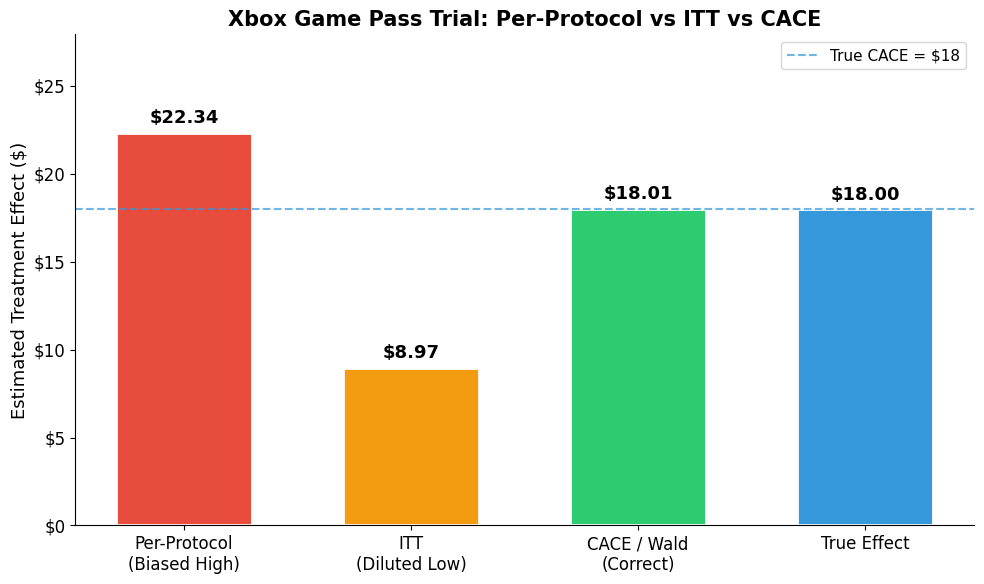

In [8]:
estimates = {
    'Per-Protocol\n(Biased High)': per_protocol,
    'ITT\n(Diluted Low)': itt,
    'CACE / Wald\n(Correct)': cace,
    'True Effect': TRUE_CACE
}

colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(estimates.keys(), estimates.values(), color=colors, edgecolor='white', linewidth=2, width=0.6)

for bar, val in zip(bars, estimates.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.axhline(y=TRUE_CACE, color='#3498db', linestyle='--', alpha=0.7, linewidth=1.5, label=f'True CACE = ${TRUE_CACE}')
ax.set_ylabel('Estimated Treatment Effect ($)', fontsize=13)
ax.set_title('Xbox Game Pass Trial: Per-Protocol vs ITT vs CACE', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(estimates.values()) * 1.25)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Weak Instrument Problem: What Happens When Compliance Drops?

When the compliance rate is low (few people respond to the instrument), the CACE estimate becomes **noisy and unstable**. This is the weak instrument problem — dividing by a small number amplifies estimation error.

Let's simulate how the CACE estimate behaves as compliance drops from 80% down to 5%.

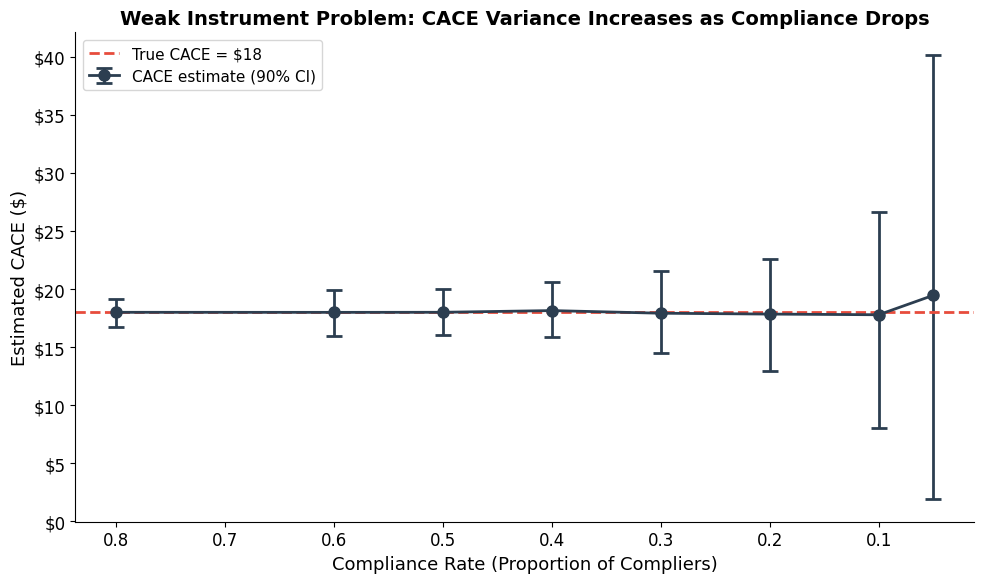


CACE estimate stability by compliance rate:
Compliance    Mean CACE    Std Dev               90% CI
-------------------------------------------------------
     80%     $   17.99 $    0.78   [  16.7,   19.1]
     60%     $   17.99 $    1.16   [  16.0,   19.9]
     50%     $   18.00 $    1.20   [  16.0,   20.0]
     40%     $   18.14 $    1.52   [  15.9,   20.6]
     30%     $   17.92 $    2.10   [  14.5,   21.6]
     20%     $   17.84 $    3.17   [  13.0,   22.6]
     10%     $   17.78 $    5.76   [   8.0,   26.6]
      5%     $   19.45 $   12.25   [   1.9,   40.2]


In [9]:
compliance_levels = [0.80, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05]
n_sims = 200
n_per_sim = 10_000
always_taker_rate = 0.10

results = []

for comp_rate in compliance_levels:
    never_taker_rate = 1.0 - comp_rate - always_taker_rate
    cace_estimates = []

    for _ in range(n_sims):
        types = np.random.choice(
            ['complier', 'always_taker', 'never_taker'],
            size=n_per_sim,
            p=[comp_rate, always_taker_rate, never_taker_rate]
        )
        z = np.concatenate([np.ones(n_per_sim // 2, dtype=int), np.zeros(n_per_sim // 2, dtype=int)])
        np.random.shuffle(z)

        t = np.zeros(n_per_sim, dtype=int)
        t[(types == 'complier') & (z == 1)] = 1
        t[types == 'always_taker'] = 1

        y = np.random.normal(120, 30, n_per_sim) + np.where(t == 1, TRUE_CACE, 0) + np.random.normal(0, 10, n_per_sim)

        itt_sim = y[z == 1].mean() - y[z == 0].mean()
        cr_sim = t[z == 1].mean() - t[z == 0].mean()
        if cr_sim > 0.001:
            cace_estimates.append(itt_sim / cr_sim)

    results.append({
        'compliance_rate': comp_rate,
        'mean_cace': np.mean(cace_estimates),
        'std_cace': np.std(cace_estimates),
        'p5': np.percentile(cace_estimates, 5),
        'p95': np.percentile(cace_estimates, 95)
    })

res_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(res_df['compliance_rate'], res_df['mean_cace'],
            yerr=[res_df['mean_cace'] - res_df['p5'], res_df['p95'] - res_df['mean_cace']],
            fmt='o-', color='#2c3e50', capsize=6, capthick=2, linewidth=2, markersize=8, label='CACE estimate (90% CI)')
ax.axhline(y=TRUE_CACE, color='#e74c3c', linestyle='--', linewidth=2, label=f'True CACE = ${TRUE_CACE}')
ax.set_xlabel('Compliance Rate (Proportion of Compliers)', fontsize=13)
ax.set_ylabel('Estimated CACE ($)', fontsize=13)
ax.set_title('Weak Instrument Problem: CACE Variance Increases as Compliance Drops',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.invert_xaxis()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nCACE estimate stability by compliance rate:")
print(f"{'Compliance':<12} {'Mean CACE':>10} {'Std Dev':>10} {'90% CI':>20}")
print("-" * 55)
for _, row in res_df.iterrows():
    print(f"{row['compliance_rate']:>8.0%}     ${row['mean_cace']:>8.2f} ${row['std_cace']:>8.2f}   [{row['p5']:>6.1f}, {row['p95']:>6.1f}]")

## Key Takeaways

### When to use each estimate

| Estimate | Use when... | Reports... |
|----------|------------|------------|
| **ITT** | You want a conservative, unbiased estimate of the *policy* effect | Effect of offering/assigning treatment, averaged over everyone |
| **CACE** | You want the treatment effect for people who actually respond to the instrument | Causal effect for compliers — those whose behavior changes due to assignment |
| **Per-protocol** | Almost never — only if compliance is truly random (it rarely is) | Biased comparison that conflates selection with treatment |

### Critical points

1. **Per-protocol is almost always biased**: Comparing treated vs. untreated destroys randomization. In our Xbox example, it overestimated by ~\$3-5 because always-takers have higher baseline spending.

2. **ITT is always valid but diluted**: It preserves randomization but averages the effect over compliers AND non-compliers. The more non-compliance, the more diluted.

3. **CACE recovers the complier-specific effect**: By dividing ITT by the compliance rate, we "undo" the dilution. But this requires the monotonicity and exclusion restriction assumptions.

4. **Low compliance = weak instrument = noisy CACE**: When few people comply, you're dividing by a small number, amplifying noise. Rule of thumb: compliance rate below 10-15% is a warning sign.

5. **CACE is a *local* estimate**: It tells you the effect for compliers only — not for always-takers or never-takers. This is why it's also called the Local Average Treatment Effect (LATE). It may not generalize to the full population.